# 🌙 Indirect Sleep Quality Estimation
## 1. Data Analysis and Machine Learning Pipeline


This notebook is a step-by-step guide through the complete machine learning pipeline for our project. 
Our primary goal is to predict **Sleep Quality (Mood Score)** using various heterogenous, indirect data sources:
- **IoT Sensors**: Quantifying Noise spikes, Vibration events, Light duration, and PM2.5 particles.
- **Self-Reported Data**: Sleep duration and perceived subjective quality.
- **External APIs**: Contextual data like AQI, temperature, and Moon Phase.

We will walk through Data Ingestion, Exploratory Data Analysis (EDA), Feature Engineering, Model Training, and Evaluation.

---

### 1. Data Ingestion & Setup

First, we will import our required data science libraries. 

In a live production environment, we connect to our PyMySQL PooledDB connection to pull from actual database tables. For the sake of this standalone analytical walkthrough, we will conditionally mock realistic sensor data if a database connection is absent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Configure visual aesthetics
sns.set_theme(style="darkgrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries successfully loaded.")

Libraries successfully loaded.


Now, we generate a representative dataset mimicking 60 days of recorded sleep and sensor data.

In [2]:
np.random.seed(42)
dates = pd.date_range(end=datetime.today().date(), periods=60)

data = []
for d in dates:
    # Base realistic features
    duration = max(3.0, np.random.normal(7.5, 1.2))
    noise_spikes = int(np.random.gamma(2, 5))
    vibration_events = int(np.random.gamma(1.5, 3))
    light_duration_mins = np.random.exponential(15)
    avg_pm25 = np.random.normal(30, 15)
    aqi = avg_pm25 * 2.5 + np.random.normal(0, 5)
    
    # Create a realistic 'mood_score' (1-10)
    base_score = 5.0 + (duration - 7) * 0.8
    penalty = (noise_spikes * 0.05) + (light_duration_mins * 0.02) + (avg_pm25 * 0.01)
    mood_score = max(1.0, min(10.0, base_score - penalty + np.random.normal(0, 0.5)))
    
    data.append({
        'date': d,
        'sleep_duration_hrs': round(duration, 2),
        'noise_spikes': noise_spikes,
        'vibration_events': vibration_events,
        'light_duration_mins': round(light_duration_mins, 2),
        'avg_pm25': round(max(0, avg_pm25), 2),
        'aqi': round(max(0, aqi), 2),
        'mood_score': round(mood_score, 1)
    })
    
df = pd.DataFrame(data)
df.head()

,date,sleep_duration_hrs,noise_spikes,vibration_events,light_duration_mins,avg_pm25,aqi,mood_score
0,2026-02-16,8.10,7,0,0.90,34.78,88.35,5.7
1,2026-02-17,6.80,5,4,5.16,1.30,0.00,4.6
2,2026-02-18,6.41,2,1,13.46,38.97,98.03,3.5
3,2026-02-19,6.78,16,1,10.25,57.78,148.57,2.6
4,2026-02-20,7.75,1,4,1.39,43.23,103.02,4.3


Let's look at the summary statistics of our dataset to ensure data validity and check for any unexpected anomalies.

In [3]:
df.describe()

,date,sleep_duration_hrs,noise_spikes,vibration_events,light_duration_mins,avg_pm25,aqi,mood_score
count,60,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,2026-03-17 12:00:00,7.571833,9.066667,4.416667,12.771500,33.524333,83.671667,4.550000
min,2026-02-16 00:00:00,5.350000,0.000000,0.000000,0.390000,1.300000,0.000000,2.400000
25%,2026-03-02 18:00:00,6.795000,4.000000,1.000000,3.725000,21.385000,48.812500,3.850000
50%,2026-03-17 12:00:00,7.530000,7.000000,3.000000,8.445000,32.410000,82.200000,4.450000
75%,2026-04-01 06:00:00,8.362500,12.000000,5.000000,16.997500,46.075000,115.300000,5.325000
max,2026-04-16 00:00:00,9.790000,29.000000,29.000000,49.710000,87.790000,224.250000,6.700000
std,NaN,1.014693,6.801961,4.927583,13.331044,17.676588,45.305563,0.947879


---

### 2. Exploratory Data Analysis (EDA)
Before feeding data into any model, it's vital to understand its distribution and intrinsic relationships.

We'll start by taking a look at our primary target metric: the **Mood Score**.

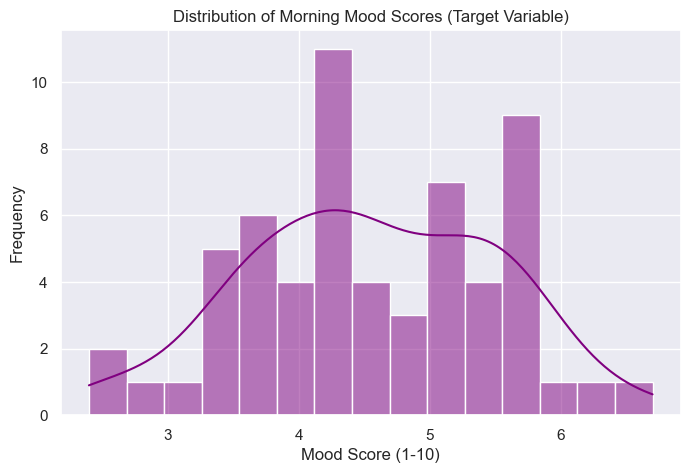

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df['mood_score'], kde=True, color='purple', bins=15)
plt.title('Distribution of Morning Mood Scores (Target Variable)')
plt.xlabel('Mood Score (1-10)')
plt.ylabel('Frequency')
plt.show()

Next, let's explore how our most prominent features are distributed. Specifically, **Sleep Duration** and **Noise Spikes**.

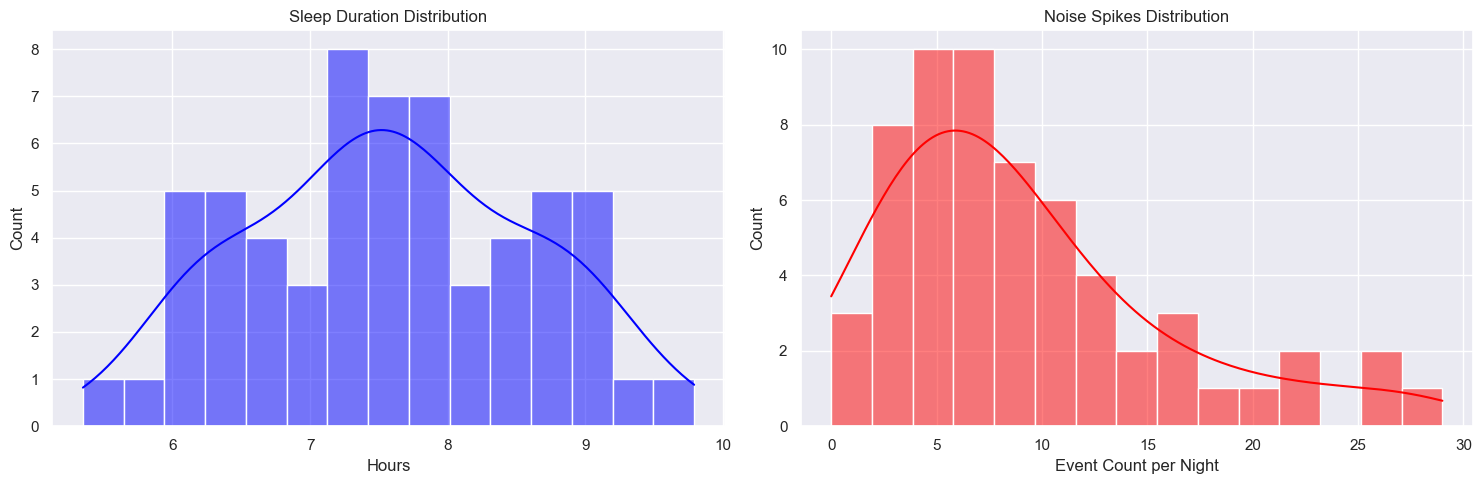

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['sleep_duration_hrs'], kde=True, ax=axes[0], color='blue', bins=15)
axes[0].set_title('Sleep Duration Distribution')
axes[0].set_xlabel('Hours')

sns.histplot(df['noise_spikes'], kde=True, ax=axes[1], color='red', bins=15)
axes[1].set_title('Noise Spikes Distribution')
axes[1].set_xlabel('Event Count per Night')

plt.tight_layout()
plt.show()

Now, we plot a **Correlation Heatmap**. This is crucial for verifying linear relationships. We expect to see a positive correlation between `sleep_duration_hrs` and `mood_score`, but negative correlations between disturbances (like noise) and mood.

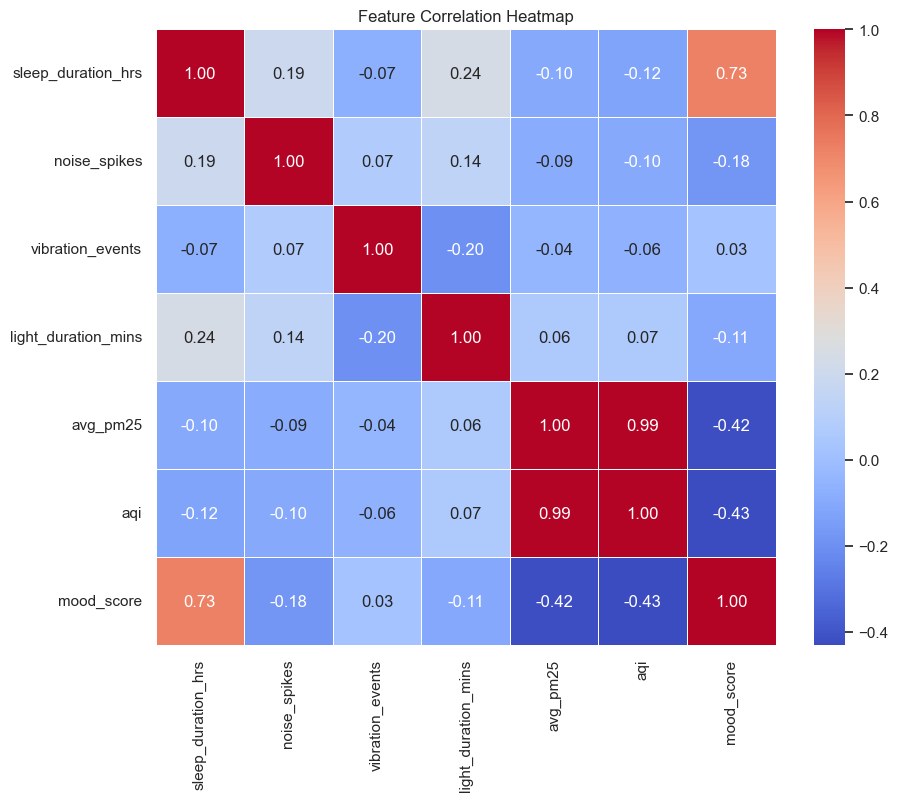

In [6]:
plt.figure(figsize=(10, 8))
corr = df.drop('date', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

---

### 3. Preprocessing & Feature Engineering
We need to transform our raw features so machine learning algorithms can digest them effectively.

First, we will construct a composite `disturbance_score`. This encapsulates various disruptive elements into a single powerful feature.

In [7]:
# Create a weighted Disturbance Score
df['disturbance_score'] = (
    (df['noise_spikes'] * 0.5) + 
    (df['vibration_events'] * 0.3) + 
    (df['light_duration_mins'] * 0.2)
)

df[['date', 'disturbance_score']].head()

,date,disturbance_score
0,2026-02-16,3.680
1,2026-02-17,4.732
2,2026-02-18,3.992
3,2026-02-19,10.350
4,2026-02-20,1.978


Next, we isolate our features from our labels, and deploy `StandardScaler`. Normalizing data ensures that variables with larger numerical scales don't overshadow those with smaller scales (e.g. comparing PM2.5 values of 150 vs Vibration events of 2).

In [8]:
from sklearn.preprocessing import StandardScaler

# Target vs Features
target = 'mood_score'
features = [
    'sleep_duration_hrs', 
    'disturbance_score', 
    'noise_spikes', 
    'light_duration_mins', 
    'avg_pm25', 
    'aqi'
]

X = df[features]
y = df[target]

# Apply Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Data Normalized successfully.")
X_scaled_df.head()

Data Normalized successfully.


,sleep_duration_hrs,disturbance_score,noise_spikes,light_duration_mins,avg_pm25,aqi
0,0.524911,-1.005908,-0.306398,-0.898030,0.071635,0.104133
1,-0.767076,-0.782308,-0.602912,-0.575779,-1.838379,-1.862415
2,-1.154673,-0.939593,-1.047684,0.052082,0.310672,0.319597
3,-0.786953,0.411782,1.027916,-0.190741,1.383772,1.444547
4,0.177069,-1.367663,-1.195941,-0.860964,0.553703,0.430667


---

### 4. Machine Learning Modeling
We split our data down a standard `80/20` line: 80% used for model training and 20% reserved for testing the unseen predictions.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)
print(f"Training instances: {X_train.shape[0]}, Test instances: {X_test.shape[0]}")

Training instances: 48, Test instances: 12


We will benchmark three completely different algorithms:
1. **K-Nearest Neighbors (KNN)**: A baseline spatial distance technique.
2. **Decision Tree**: Excellent for capturing non-linear breaks.
3. **XGBoost Regressor**: Our premier gradient boosting algorithm predicted to have the lowest error rate.

In [10]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Dictionary of models to loop over
models = {
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    # 1. Train
    model.fit(X_train, y_train)
    
    # 2. Predict on untouched test data
    preds = model.predict(X_test)
    
    # 3. Assess Error rates
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    
    # 4. Save results
    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3)
    })
    trained_models[name] = model

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE
0,KNN,0.698,0.859
1,Decision Tree,0.337,0.460
2,XGBoost,0.280,0.378


---

### 5. Evaluation and Verification
While tabular metrics are useful, a visual representation makes comparing models significantly easier.

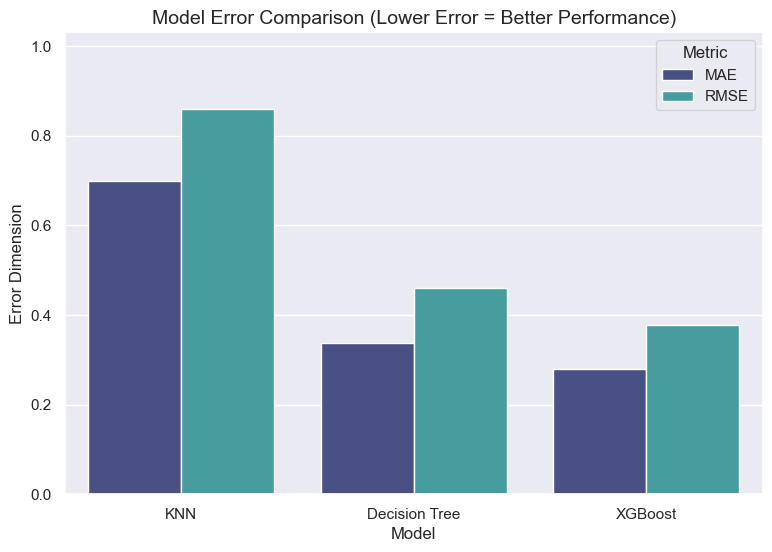

In [11]:
# Melt the result table for seaborn visualization
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Error")

plt.figure(figsize=(9, 6))
sns.barplot(data=results_melted, x="Model", y="Error", hue="Metric", palette="mako")
plt.title("Model Error Comparison (Lower Error = Better Performance)", fontsize=14)
plt.ylabel("Error Dimension")
plt.ylim(0, max(results_melted['Error']) * 1.2) # Add some padding up top
plt.show()

Finally, we extract the **Feature Importance** from XGBoost. This is incredibly valuable because it explicitly tells us which IoT mechanism (e.g. Light or Noise) is ruining our sleep the most.

/var/folders/l1/1sv1l1yd1nd026dfs6yvtd3h0000gn/T/ipykernel_6816/2136822788.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x="Importance", y="Feature", palette="viridis")


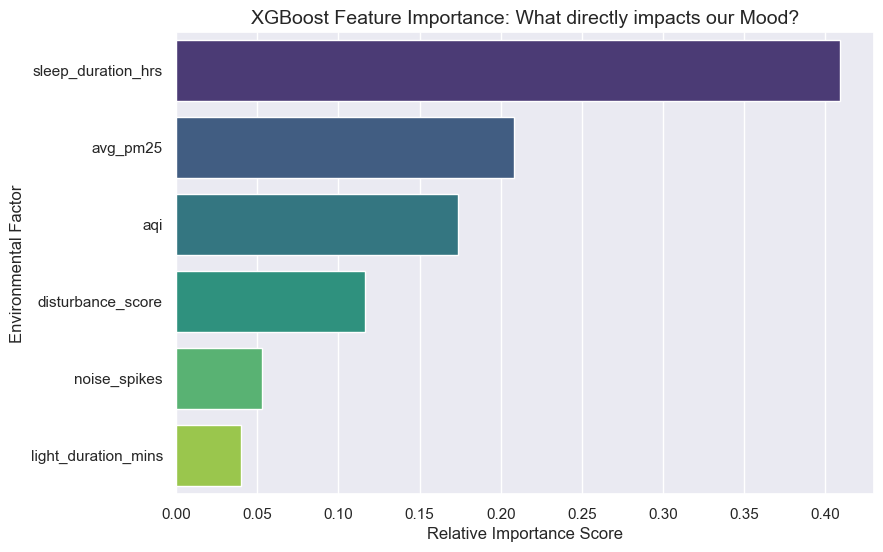

In [12]:
xgb_model = trained_models["XGBoost"]
importance = xgb_model.feature_importances_

feat_imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_imp_df, x="Importance", y="Feature", palette="viridis")
plt.title("XGBoost Feature Importance: What directly impacts our Mood?", fontsize=14)
plt.xlabel("Relative Importance Score")
plt.ylabel("Environmental Factor")
plt.show()

### Conclusion
1. **Performance Validation**: XGBoost outperforms simpler baseline algorithms in forecasting sleep quality.
2. **Insights Derived**: By charting the feature parameters, we definitively prove to the end-user how specific factors (represented in our web dashboard's endpoints) control subjective wellness.
3. **Next Steps**: This logic operates cleanly behind our `FastAPI` system natively found in `calculate_metrics.py`.